In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


### Imports

In [2]:
import gc
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
%matplotlib inline

from tensorflow.keras import backend as K # Importing Keras backend (by default it is Tensorflow)
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.callbacks import EarlyStopping # Callback for early stopping
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.layers import Input, Dense, Dropout # Layers to be used for building our model
from tensorflow.keras.models import Model # The class used to create a model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.random import set_seed

print("Tensorflow version " + tf.__version__)

Tensorflow version 2.19.0


### Data manipulation

**Task**: Given an image of handwritten digit find the digit

**Data**:
- The data are grayscale 28*28 images of scanned handwritten digits
- We will use a CNN to classify them (no need to flatten as when using an MLP)
- The values of the inputs are in [0, 255] so we normalize them to [0, 1]

In [3]:
batch_size = 128
classes = 100

(X_train, y_train), (X_test, y_test) = cifar100.load_data()
input_shape = (X_train.shape[1], X_train.shape[2], X_train.shape[3])
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255
Y_train = to_categorical(y_train, classes)
Y_test = to_categorical(y_test, classes)

### Plotting results

In [4]:
def plot_history(hs, epochs, metric, max_y):
    print()
    plt.style.use('dark_background')
    plt.rcParams['figure.figsize'] = [15, 8]
    plt.rcParams['font.size'] = 16
    plt.clf()
    for label in hs:
        plt.plot(
            np.arange(hs[label]['x_start'], hs[label]['x_start'] + len(hs[label]['history'].history[metric])),
            hs[label]['history'].history[metric],
            label=f'{label} train {metric}',
            linewidth=2
        )
        plt.plot(
            np.arange(hs[label]['x_start'], hs[label]['x_start'] + len(hs[label]['history'].history[metric])),
            hs[label]['history'].history[f'val_{metric}'],
            label=f'{label} validation {metric}',
            linewidth=2
        )
    x_ticks = np.arange(0, epochs + 1, epochs / 10)
    x_ticks[0] += 1
    plt.xticks(x_ticks)
    plt.ylim((0, max_y))
    plt.xlabel('Epochs')
    plt.ylabel('Loss' if metric=='loss' else 'Accuracy')
    plt.legend()
    plt.show()


### Cleaning up

In [5]:
def clean_up(model):
    K.clear_session()
    del model
    gc.collect()


### Model creation

- We will use a Functional Model.
    - It is more flexible than the `Sequential` model but ...
    - We need to be careful with the sizes of the layers.
- The first layer should always be an `Input` layer where we specify the input of the model, e.g., the training data
- The other layers can be whatever we want and for each layer we must:
    - Define the input to the layer, i.e., another layer.
    - Define the number of units which also defines the output size.
        - The output size must be always equal to the number of units of the next layer.


In [6]:
def train_model(
        upper_layers_optimizer,
        full_network_optimizer,
        upper_layers_epochs=30,
        full_network_epochs=70,
        batch_size=128,
        mlp_hidden_layers=[1024, 1024, 512],
        mlp_hidden_activation='relu',
        mlp_dropout=0.2,
        output_activation='softmax',
        callbacks=None,
        verbose=0):

    np.random.seed(1402) # Define the seed for numpy to have reproducible experiments.
    set_seed(1981) # Define the seed for Tensorflow to have reproducible experiments.

    base_model = VGG19(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
        pooling='max',
    )

    x = base_model.output
    # Define MLP layers.
    for i, units in enumerate(mlp_hidden_layers):
        x = Dense(
            units=units,
            kernel_initializer='glorot_uniform',
            activation=mlp_hidden_activation,
            name='Hidden-{0:d}'.format(i + 1)
        )(x)
        if mlp_dropout > 0:
            x = Dropout(rate=mlp_dropout)(x)


    # Define the output layer.
    output = Dense(
        units=classes,
        activation=output_activation,
        name='Output'
    )(x)

    # Define the model and train it.
    model = Model(inputs=base_model.input, outputs=output)

    # First train the upper layers for a few epochs
    for layer in base_model.layers:
        layer.trainable = False

    model.compile(optimizer=upper_layers_optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    hs_upper_layers = model.fit(
        x=X_train,
        y=Y_train,
        validation_split=0.1, # use 10% of the training data as validation data
        epochs=upper_layers_epochs,
        verbose=verbose,
        callbacks=callbacks,
        batch_size=batch_size
    )
    print('Finished training upper layers.')
    print('------------------')

    model.summary() # Print a description of the model.

    # Now train the whole network with a low learning rate
    for layer in base_model.layers:
        layer.trainable = True

    model.compile(optimizer=full_network_optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    hs_full_network = model.fit(
        x=X_train,
        y=Y_train,
        validation_split=0.1, # use 10% of the training data as validation data
        epochs=full_network_epochs,
        verbose=verbose,
        callbacks=callbacks,
        batch_size=batch_size
    )
    print('Finished training full network.')
    print('------------------')

    model.summary() # Print a description of the model.
    return model, hs_upper_layers, hs_full_network


###Using Early Stopping with patience 10

In [7]:
# Using Adam
upper_layers_optimizer = Adam()
full_network_optimizer = Adam(1e-5)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

# 3 Fully Connected Layers and Logistic Regression
vgg_cifar_model, vgg_upper_hs, vgg_full_network_hs = train_model(
    upper_layers_optimizer=upper_layers_optimizer,
    full_network_optimizer=full_network_optimizer,
    batch_size=batch_size,
    mlp_hidden_layers=[1024, 1024, 512],
    mlp_hidden_activation='relu',
    mlp_dropout=0.2,
    output_activation='softmax',
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate on test data and show all the results.
vgg_cifar_eval = vgg_cifar_model.evaluate(X_test, Y_test, verbose=1)
clean_up(model=vgg_cifar_model)

Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.1055 - loss: 3.9189 - val_accuracy: 0.2436 - val_loss: 3.0600
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2394 - loss: 3.0755 - val_accuracy: 0.2804 - val_loss: 2.9049
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2769 - loss: 2.8775 - val_accuracy: 0.2912 - val_loss: 2.8398
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3077 - loss: 2.7411 - val_accuracy: 0.3006 - val_loss: 2.8006
Epoch 5/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3255 - loss: 2.6288 - val_accuracy: 0.3032 - val_loss: 2.7886
Epoch 6/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3479 - loss: 2.5225 - val_accuracy: 0.3112 - val_loss: 2.7665
Epoch 7/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3665 - loss: 2.4249 - val_accuracy: 0.3186 - val_loss: 2.7715
Epoch 8/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3801 - loss: 2.3488 - val_accuracy: 

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 512)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden-1 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 26,477,422 (101.00 MB)

 Trainable params: 2,151,012 (8.21 MB)

...

 Total params: 66,526,190 (253.78 MB)

 Trainable params: 22,175,396 (84.59 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 44,350,794 (169.18 MB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.4384 - loss: 2.9925


Upper Layers Evaluation:
---
Train Loss     : 1.20481
Validation Loss: 3.42190
---
Train Accuracy     : 0.63922
Validation Accuracy: 0.31600
Full Network Evaluation:
---
Train Loss     : 0.42368
Validation Loss: 3.45545
---
Train Accuracy     : 0.86436
Validation Accuracy: 0.41800

---
Test Loss    : 2.99567
Test Accuracy: 0.43810



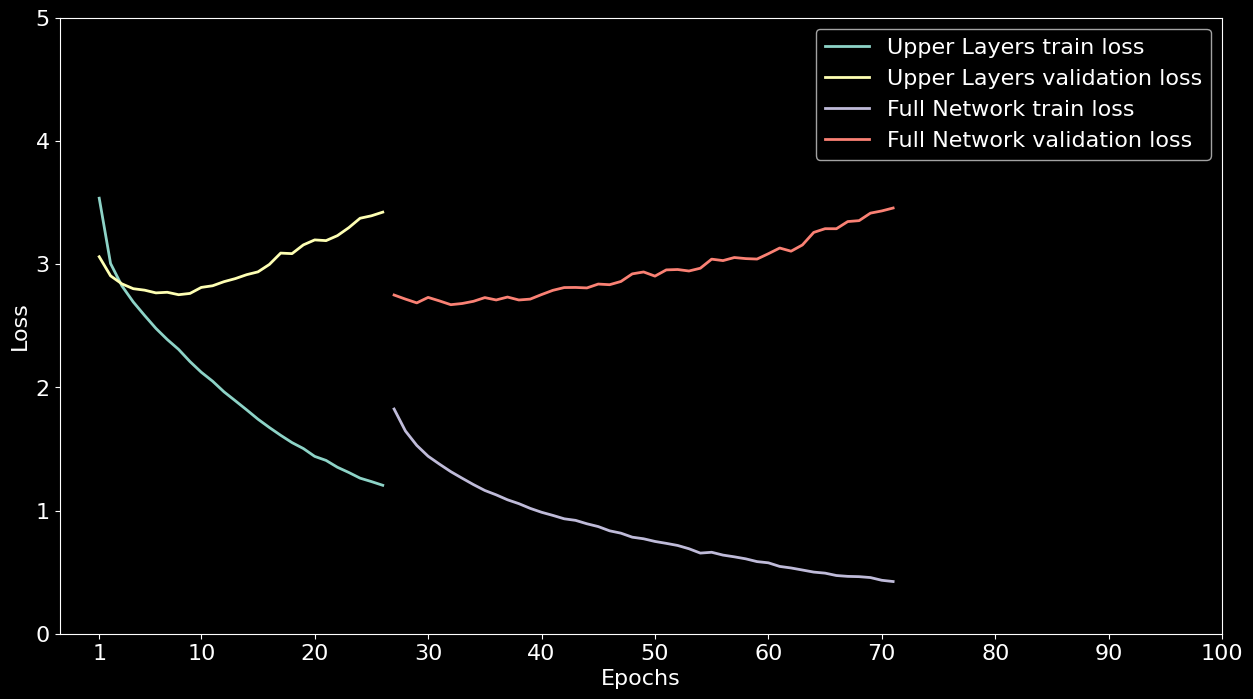

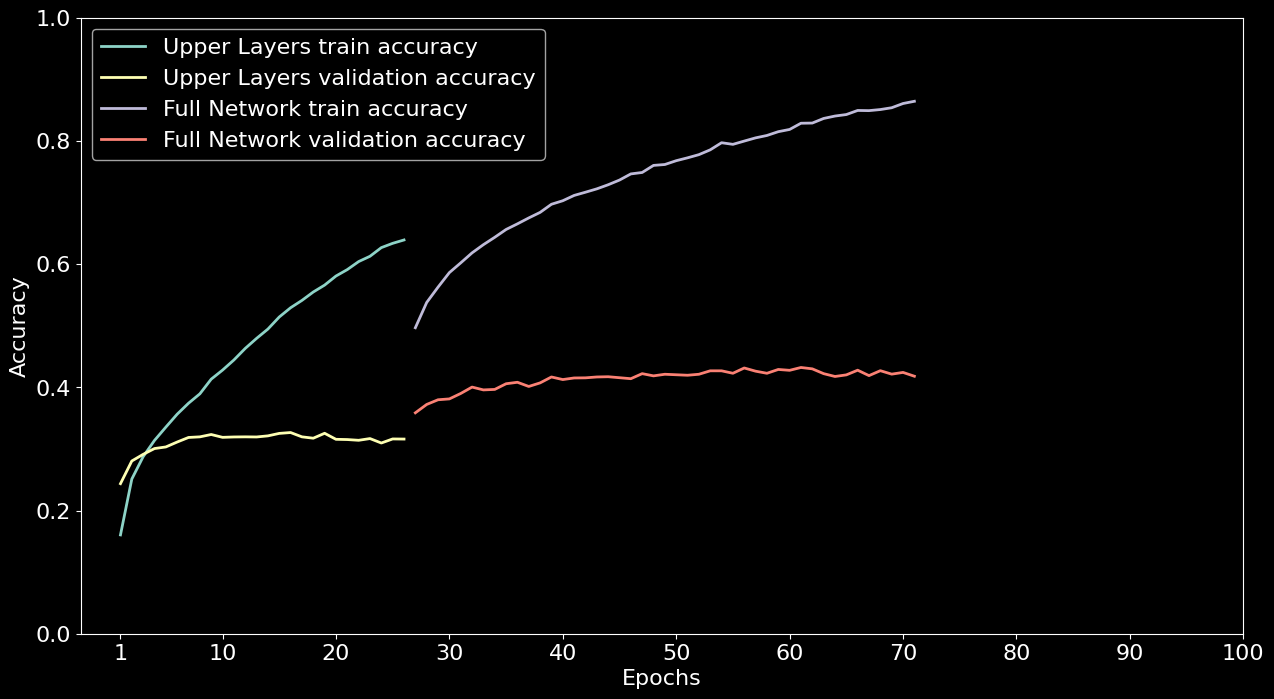

In [8]:
print("Upper Layers Evaluation:")
print("---")
print("Train Loss     : {0:.5f}".format(vgg_upper_hs.history['loss'][-1]))
print("Validation Loss: {0:.5f}".format(vgg_upper_hs.history['val_loss'][-1]))
print("---")
print("Train Accuracy     : {0:.5f}".format(vgg_upper_hs.history['accuracy'][-1]))
print("Validation Accuracy: {0:.5f}".format(vgg_upper_hs.history['val_accuracy'][-1]))


print("Full Network Evaluation:")
print("---")
print("Train Loss     : {0:.5f}".format(vgg_full_network_hs.history['loss'][-1]))
print("Validation Loss: {0:.5f}".format(vgg_full_network_hs.history['val_loss'][-1]))
print("---")
print("Train Accuracy     : {0:.5f}".format(vgg_full_network_hs.history['accuracy'][-1]))
print("Validation Accuracy: {0:.5f}".format(vgg_full_network_hs.history['val_accuracy'][-1]))

print()
print('---')
print("Test Loss    : {0:.5f}".format(vgg_cifar_eval[0]))
print("Test Accuracy: {0:.5f}".format(vgg_cifar_eval[1]))


# Plot train and validation error per epoch.
plot_history(
    hs={
        'Upper Layers': {'history': vgg_upper_hs, 'x_start': 1},
        'Full Network': {'history': vgg_full_network_hs, 'x_start': len(vgg_upper_hs.history['loss']) + 1}
    },
    epochs=100,
    metric='loss',
    max_y=5
)
plot_history(
    hs={
        'Upper Layers': {'history': vgg_upper_hs, 'x_start': 1},
        'Full Network': {'history': vgg_full_network_hs, 'x_start': len(vgg_upper_hs.history['loss']) + 1}
    },
    epochs=100,
    metric='accuracy',
    max_y=1
)

In [9]:
exit()